In [1]:
from torchvision import transforms, datasets
from torch.utils.data import WeightedRandomSampler
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

In [2]:
dataset_dir = Path('../dataset/aptos2019')

train_dir = dataset_dir / 'train'
validation_dir = dataset_dir / 'validation'
test_dir = dataset_dir / 'test_images'


In [3]:
train_dataset = datasets.ImageFolder(train_dir)

In [4]:
Counter(train_dataset.targets)

Counter({0: 1605, 2: 912, 1: 340, 4: 262, 3: 176})

In [5]:
minority_classes = [1, 4, 3]
majority_classes = [0, 2]

## Create transform for minority and majority classes

In [6]:
# %%writefile '../Modules/transforms.py'

from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image

minority_classes = [1, 4, 3]
majority_classes = [0, 2]

normalize = transforms.Normalize(

    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

minority_transform = transforms.Compose([

    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=15),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAutocontrast(),
    transforms.RandomGrayscale(p=0.5),
    transforms.ToTensor(),
    normalize
])

majority_transform = transforms.Compose([
    
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=5),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize
])

validation_transform = transforms.Compose([

    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize
])

def get_transform(label):

    if label in minority_transform:

        return minority_transform
    
    return majority_transform


class RetinalDataset(Dataset):

    def __init__(self, image_paths, labels, is_train):
        super().__init__()

        self.image_paths = image_paths
        self.labels = labels
        self.is_train = is_train

    def __getitem__(self, index):

        image = Image.open(self.image_paths[index]).convert("RGB")
        label = self.labels[index]

        if self.is_train:

            transform = get_transform(label)

        else:

            transform = validation_transform

        image = transform(image)

        return image, label

## Create weight samplers

In [7]:
class_counts = Counter(train_dataset.targets)

class_weights = [ 1.0 / class_counts[y] for y in train_dataset.targets]

sampler = WeightedRandomSampler(
    weights=class_weights,
    num_samples=len(train_dataset),
    replacement=True
)

class_counts

Counter({0: 1605, 2: 912, 1: 340, 4: 262, 3: 176})

## Visualize image with and without transform

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

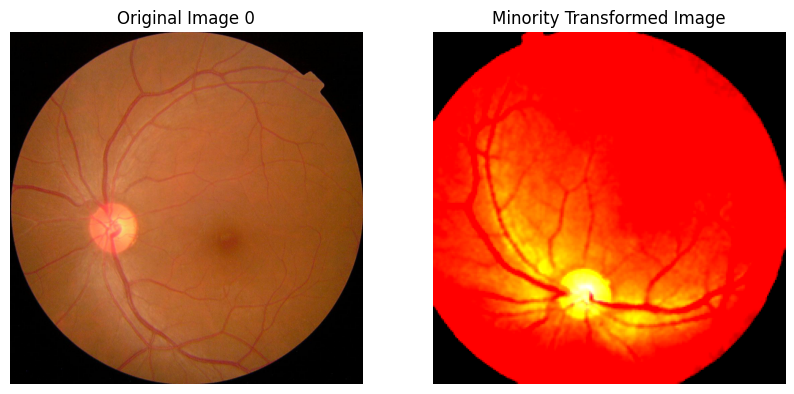

In [97]:
image, label = next(iter(train_dataset))


fig = plt.figure(figsize=(10, 10))
fig.subplots(1, 2)

plt.subplot(1, 2, 1)
plt.title(label=f"Original Image {label}")
plt.imshow(image)
plt.axis(False)


minority_transform = transforms.Compose([

    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=180),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.4,
                           contrast=0.4,
                           saturation=0.3),
    transforms.RandomAdjustSharpness(sharpness_factor=2),
    transforms.GaussianBlur(kernel_size=3,
                            sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    normalize
])


plt.subplot(1, 2, 2)
plt.title(label="Minority Transformed Image")
plt.imshow(minority_transform(image).permute(1, 2, 0))
plt.axis(False)


# plt.subplot(1, 3, 3)
# plt.title(label="Majority Transformed Image")
# plt.imshow(majority_transform(image).permute(1, 2, 0))
# plt.axis(False)
